In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

print("Libraries loaded")

Libraries loaded


In [2]:
import pandas as pd
from pathlib import Path

results_root = Path("../results_R_40")

records = []

for learner_dir in results_root.iterdir():

    if not learner_dir.is_dir():
        continue

    model = learner_dir.name

    for setting_dir in learner_dir.iterdir():

        if not setting_dir.is_dir():
            continue

        setting = setting_dir.name
        raw_file = setting_dir / "raw_results.csv"

        if not raw_file.exists():
            continue

        df = pd.read_csv(raw_file)

        df["model"] = model
        df["setting"] = setting

        records.append(df)

# combine all raw results
all_raw = pd.concat(records, ignore_index=True)

print("Loaded raw rows:", len(all_raw))


# aggregate across repetitions
aggregated = (
    all_raw
    .groupby(["model", "setting", "tuner", "rep"])
    .agg(
        pehe_mean=("pehe", "mean"),
        pehe_std=("pehe", "std"),
        pehe_plug_mean=("pehe_plug", "mean"),
        pehe_plug_std=("pehe_plug", "std")
    )
    .reset_index()
)

print("Aggregated rows:", len(aggregated))

# save
output_path = Path("../aggregated_results.csv")
aggregated.to_csv(output_path, index=False)

print(f"Saved aggregated results to: {output_path}")

aggregated.head()

Loaded raw rows: 800
Aggregated rows: 800
Saved aggregated results to: ../aggregated_results.csv


,model,setting,tuner,rep,pehe_mean,pehe_std,pehe_plug_mean,pehe_plug_std
0,x_cb,1d,bayes,0,0.099102,NaN,0.315861,NaN
1,x_cb,1d,bayes,1,0.163602,NaN,0.536343,NaN
2,x_cb,1d,bayes,2,0.216457,NaN,0.557766,NaN
3,x_cb,1d,bayes,3,0.207491,NaN,0.365726,NaN
4,x_cb,1d,bayes,4,0.159065,NaN,0.414202,NaN


In [5]:
# Aggregate by tuner across ALL settings and models
tuner_performance = aggregated.groupby(['tuner', 'rep']).agg({
    'pehe_mean': ['mean', 'std', 'min', 'max'],
    'pehe_plug_mean': ['mean', 'std', 'min', 'max']
}).round(4)

print("\n" + "="*80)
print("OVERALL TUNER PERFORMANCE (across all settings & models)")
print("="*80)
print(tuner_performance)


OVERALL TUNER PERFORMANCE (across all settings & models)
           pehe_mean                         pehe_plug_mean                  \
                mean     std     min     max           mean     std     min   
tuner  rep                                                                    
bayes  0      0.0785  0.0128  0.0626  0.0991         0.2355  0.0382  0.1890   
       1      0.1510  0.0169  0.1259  0.1716         0.4571  0.0854  0.3149   
       2      0.1878  0.0216  0.1493  0.2165         0.4486  0.1081  0.2799   
       3      0.1927  0.0262  0.1587  0.2189         0.2882  0.0619  0.2013   
       4      0.0892  0.0290  0.0698  0.1591         0.2281  0.0832  0.1397   
...              ...     ...     ...     ...            ...     ...     ...   
random 35     0.1593  0.0199  0.1278  0.1860         0.2689  0.1080  0.1173   
       36     0.1891  0.0454  0.1290  0.2863         0.1892  0.0780  0.1101   
       37     0.1231  0.0191  0.0994  0.1479         0.4210  0.0600  0.30

/var/folders/yg/yd_rkzv93459x04g3jzsjwcr0000gn/T/ipykernel_11331/1352740780.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=aggregated, x='tuner', y='pehe_mean', ax=ax1, palette='Set2')


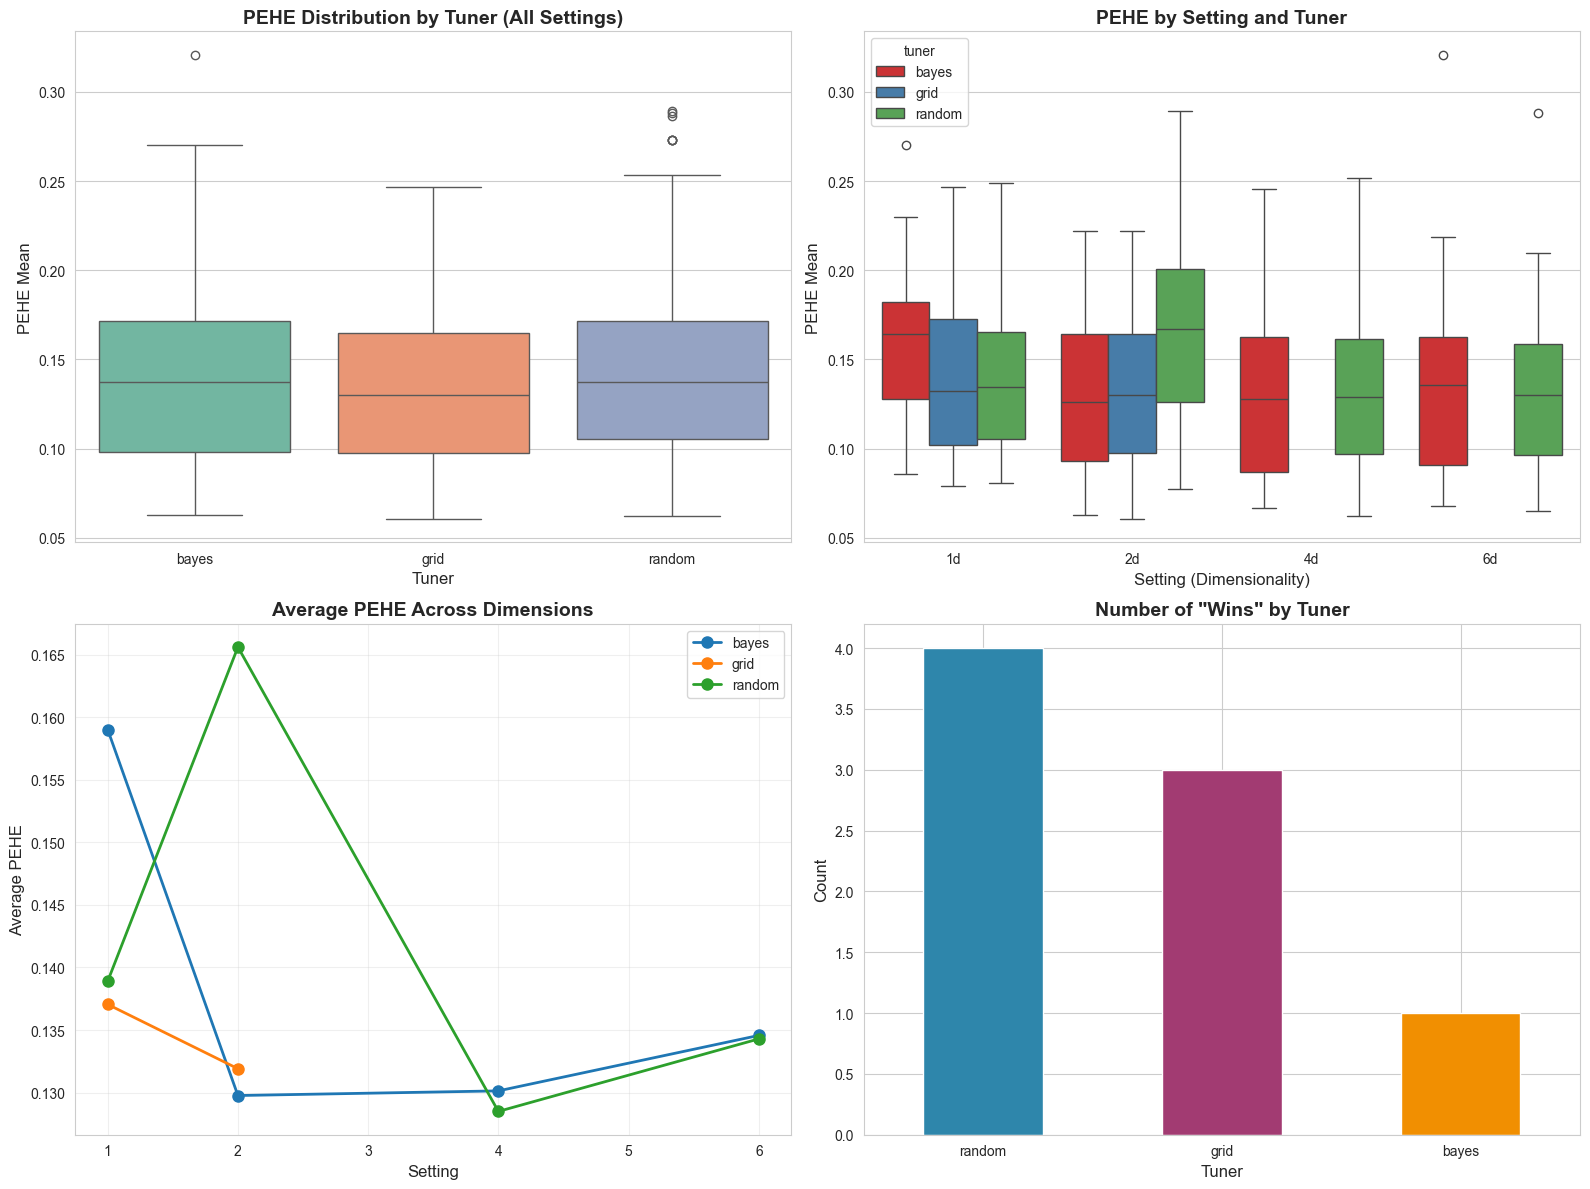

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Box plot - PEHE by tuner (all settings combined)
ax1 = axes[0, 0]
sns.boxplot(data=aggregated, x='tuner', y='pehe_mean', ax=ax1, palette='Set2')
ax1.set_title('PEHE Distribution by Tuner (All Settings)', fontsize=14, fontweight='bold')
ax1.set_ylabel('PEHE Mean', fontsize=12)
ax1.set_xlabel('Tuner', fontsize=12)

# Plot 2: Box plot - PEHE by setting
ax2 = axes[0, 1]
sns.boxplot(data=aggregated, x='setting', y='pehe_mean', hue='tuner', ax=ax2, palette='Set1')
ax2.set_title('PEHE by Setting and Tuner', fontsize=14, fontweight='bold')
ax2.set_ylabel('PEHE Mean', fontsize=12)
ax2.set_xlabel('Setting (Dimensionality)', fontsize=12)

# Plot 3: Line plot - Performance across dimensions

ax3 = axes[1, 0]

aggregated['dimension'] = aggregated['setting'].str.extract('(\d+)').astype(int)

for tuner in sorted(aggregated['tuner'].unique()):
    
    tuner_data = (
        aggregated[aggregated['tuner'] == tuner]
        .groupby('dimension')['pehe_mean']
        .mean()
        .sort_index()
    )

    ax3.plot(
        tuner_data.index,
        tuner_data.values,
        marker='o',
        label=tuner,
        linewidth=2,
        markersize=8
    )
ax3.set_title('Average PEHE Across Dimensions', fontsize=14, fontweight='bold')
ax3.set_ylabel('Average PEHE', fontsize=12)
ax3.set_xlabel('Setting', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Bar plot - Win rate by tuner
ax4 = axes[1, 1]

win_counts = []

for setting in aggregated['setting'].unique():
    for model in aggregated['model'].unique():

        subset = aggregated[
            (aggregated['setting'] == setting) &
            (aggregated['model'] == model)
        ]

        if len(subset) > 0:
            winner = subset.loc[subset['pehe_mean'].idxmin(), 'tuner']
            win_counts.append(winner)

win_df = pd.Series(win_counts).value_counts()

win_df.plot(kind='bar', ax=ax4, color=['#2E86AB', '#A23B72', '#F18F01'])

ax4.set_title('Number of "Wins" by Tuner', fontsize=14, fontweight='bold')
ax4.set_ylabel('Count', fontsize=12)
ax4.set_xlabel('Tuner', fontsize=12)
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('comprehensive_tuner_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
from itertools import combinations

print("\n" + "="*80)
print("STATISTICAL TESTS: Pairwise t-tests (PEHE)")
print("="*80)

tuners = sorted(aggregated['tuner'].unique())

for tuner1, tuner2 in combinations(tuners, 2):

    data1 = aggregated[aggregated['tuner'] == tuner1]['pehe_mean']
    data2 = aggregated[aggregated['tuner'] == tuner2]['pehe_mean']

    t_stat, p_value = stats.ttest_ind(data1, data2)

    print(f"\n{tuner1.upper()} vs {tuner2.upper()}:")
    print(f"  Mean PEHE: {data1.mean():.4f} vs {data2.mean():.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Significant at α=0.05: {'YES' if p_value < 0.05 else 'NO'}")


STATISTICAL TESTS: Pairwise t-tests (PEHE)

BAYES vs GRID:
  Mean PEHE: 0.1384 vs 0.1345
  t-statistic: 0.8898
  p-value: 0.3740
  Significant at α=0.05: NO

BAYES vs RANDOM:
  Mean PEHE: 0.1384 vs 0.1418
  t-statistic: -0.9253
  p-value: 0.3552
  Significant at α=0.05: NO

GRID vs RANDOM:
  Mean PEHE: 0.1345 vs 0.1418
  t-statistic: -1.6325
  p-value: 0.1032
  Significant at α=0.05: NO


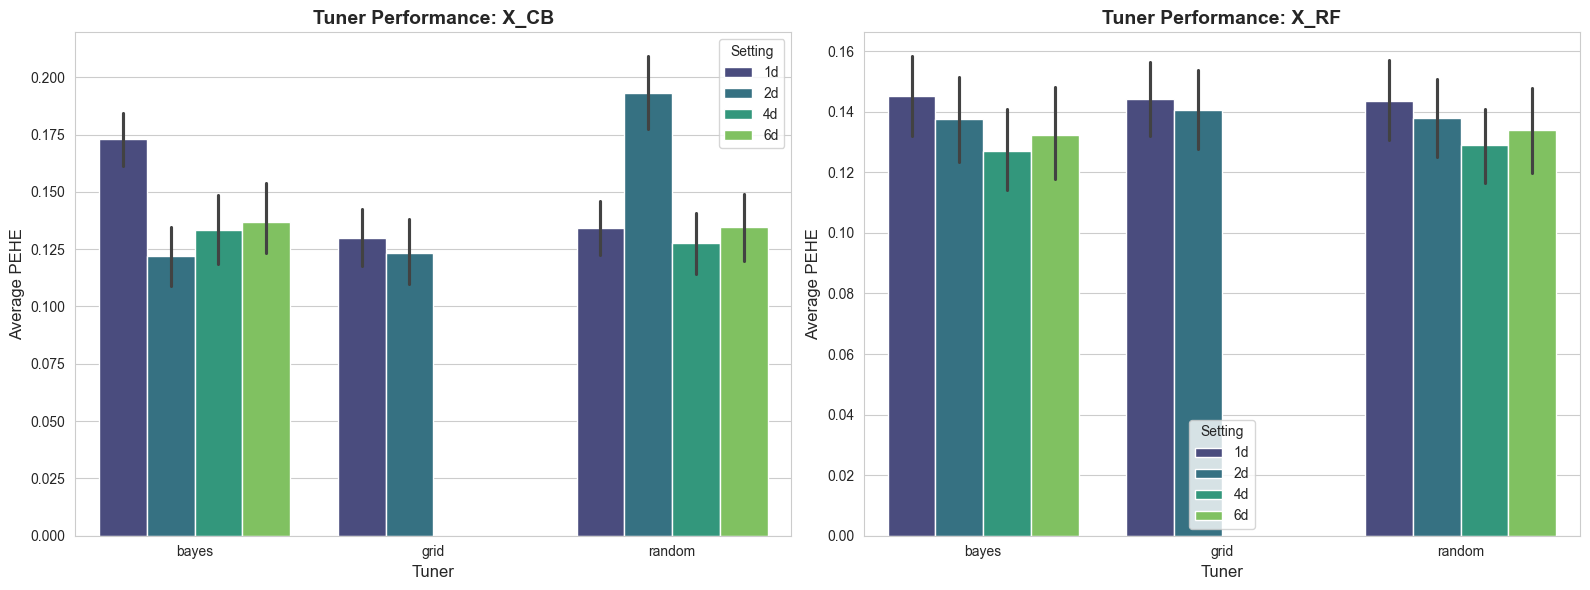

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, model in enumerate(sorted(aggregated['model'].unique())):

    ax = axes[idx]
    model_data = aggregated[aggregated['model'] == model]

    sns.barplot(
        data=model_data,
        x='tuner',
        y='pehe_mean',
        hue='setting',
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Tuner Performance: {model.upper()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average PEHE', fontsize=12)
    ax.set_xlabel('Tuner', fontsize=12)
    ax.legend(title='Setting', fontsize=10)

plt.tight_layout()
plt.savefig('model_specific_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
summary_stats = aggregated.groupby('tuner').agg({
    'pehe_mean': ['mean', 'median', 'std', 'min', 'max']
}).round(4)

summary_stats.columns = ['_'.join(col) for col in summary_stats.columns]

print("\n" + "="*80)
print("SUMMARY STATISTICS BY TUNER")
print("="*80)

print(summary_stats)

summary_stats.to_csv('../tuner_summary_statistics.csv')

print("\nSaved to: ../tuner_summary_statistics.csv")


SUMMARY STATISTICS BY TUNER
        pehe_mean_mean  pehe_mean_median  pehe_mean_std  pehe_mean_min  \
tuner                                                                    
bayes           0.1384            0.1371         0.0463         0.0626   
grid            0.1345            0.1301         0.0428         0.0605   
random          0.1418            0.1371         0.0482         0.0622   

        pehe_mean_max  
tuner                  
bayes          0.3209  
grid           0.2464  
random         0.2890  

Saved to: ../tuner_summary_statistics.csv


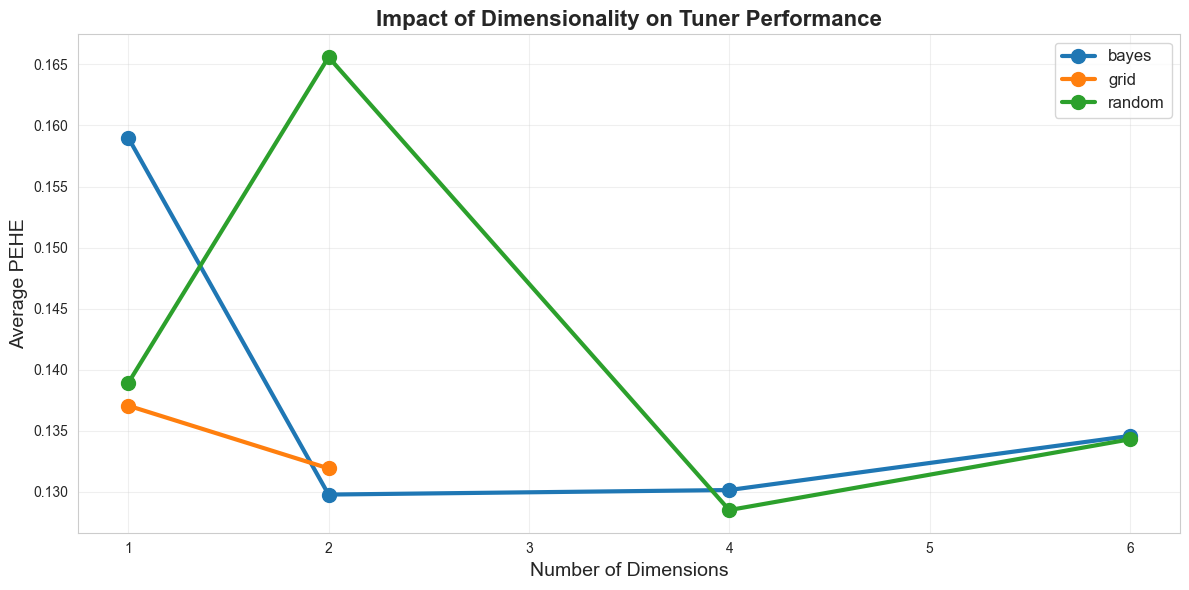

In [13]:
# Extract numeric dimension from setting
aggregated['dimension'] = aggregated['setting'].str.extract('(\\d+)').astype(int)

fig, ax = plt.subplots(figsize=(12, 6))

for tuner in sorted(aggregated['tuner'].unique()):

    tuner_data = aggregated[aggregated['tuner'] == tuner].groupby('dimension')['pehe_mean'].mean()

    ax.plot(
        tuner_data.index,
        tuner_data.values,
        marker='o',
        label=tuner,
        linewidth=3,
        markersize=10
    )

ax.set_title('Impact of Dimensionality on Tuner Performance', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Dimensions', fontsize=14)
ax.set_ylabel('Average PEHE', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dimensionality_effect.png', dpi=300, bbox_inches='tight')
plt.show()

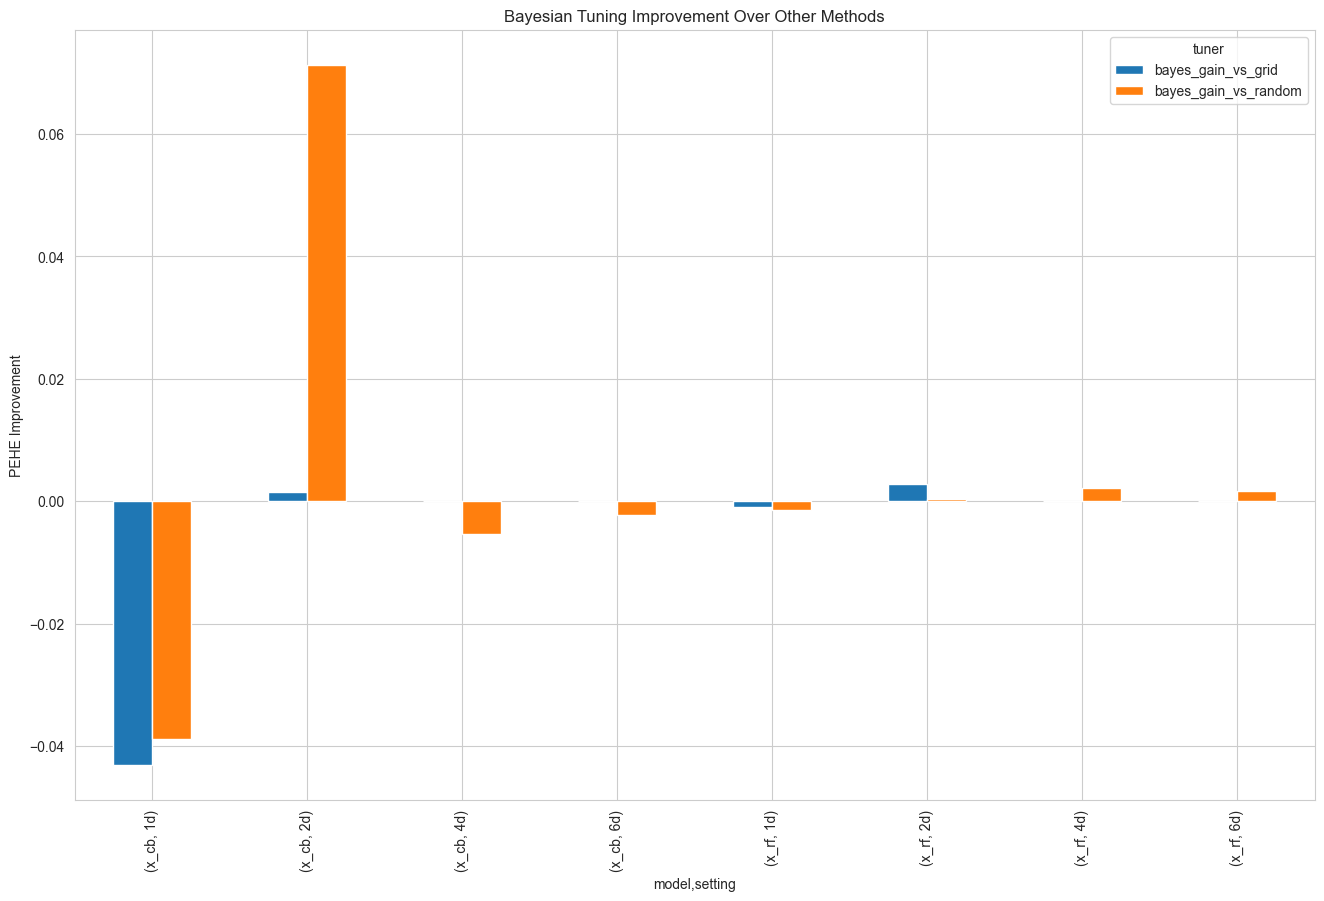

In [20]:
pivot = aggregated.pivot_table(
    index=["model","setting"],
    columns="tuner",
    values="pehe_mean"
)

pivot["bayes_gain_vs_grid"] = pivot["grid"] - pivot["bayes"]
pivot["bayes_gain_vs_random"] = pivot["random"] - pivot["bayes"]

pivot[["bayes_gain_vs_grid","bayes_gain_vs_random"]].plot(kind="bar")
plt.title("Bayesian Tuning Improvement Over Other Methods")
plt.ylabel("PEHE Improvement")
plt.show()

/var/folders/yg/yd_rkzv93459x04g3jzsjwcr0000gn/T/ipykernel_16166/1690203272.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_numeric = heatmap_df.replace(tuner_map)


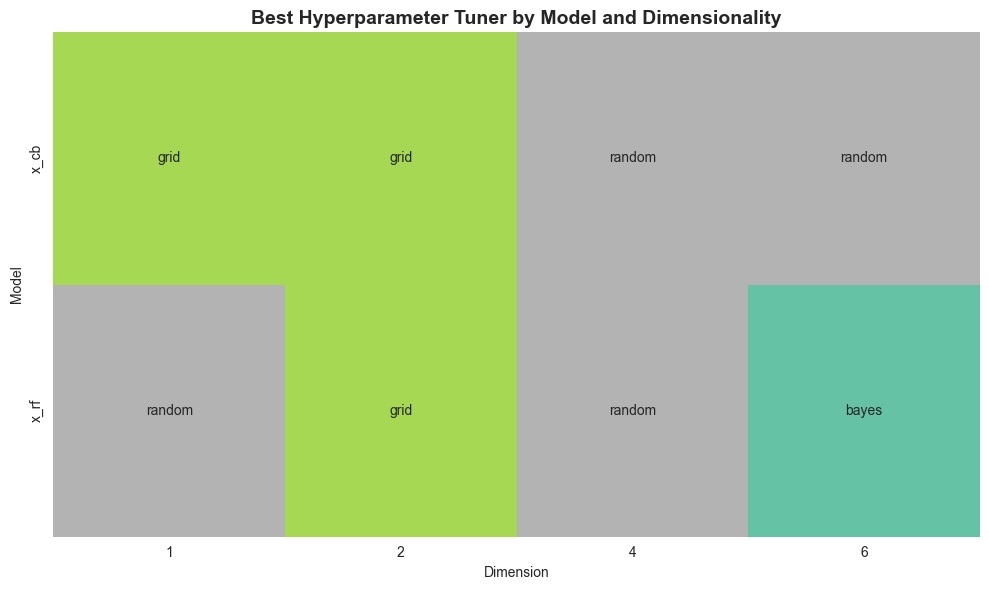

In [5]:
# Create numeric dimension
aggregated["dimension"] = aggregated["setting"].str.extract(r'(\d+)').astype(int)

# Find best tuner for each model/setting
best = (
    aggregated
    .loc[aggregated.groupby(["model","dimension"])["pehe_mean"].idxmin()]
    .sort_values(["model","dimension"])
)

# Pivot for heatmap
heatmap_df = best.pivot(index="model", columns="dimension", values="tuner")

# Convert tuner labels to numbers for coloring
tuner_map = {t:i for i,t in enumerate(sorted(aggregated["tuner"].unique()))}
heatmap_numeric = heatmap_df.replace(tuner_map)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_numeric,
    annot=heatmap_df,
    fmt="",
    cmap="Set2",
    cbar=False
)

plt.title("Best Hyperparameter Tuner by Model and Dimensionality", fontsize=14, fontweight="bold")
plt.xlabel("Dimension")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

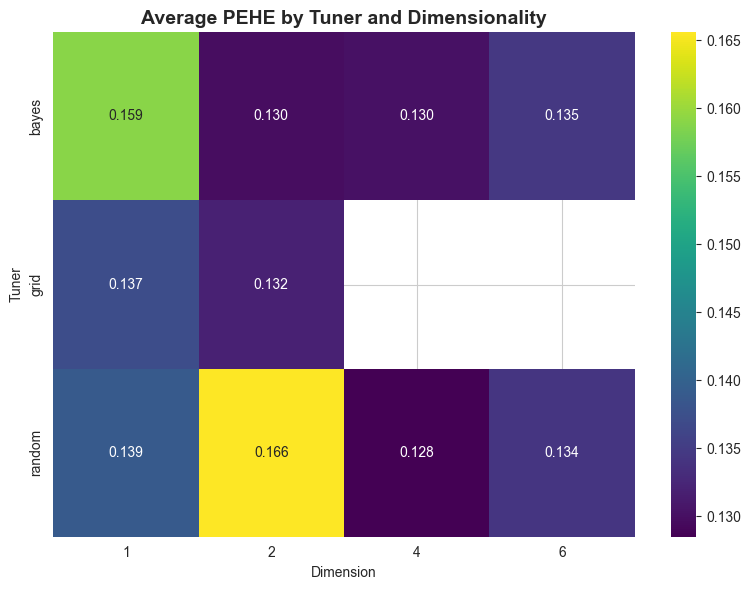

In [6]:
heatmap_df = (
    aggregated
    .groupby(["tuner","dimension"])["pehe_mean"]
    .mean()
    .unstack()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Average PEHE by Tuner and Dimensionality", fontsize=14, fontweight="bold")
plt.xlabel("Dimension")
plt.ylabel("Tuner")

plt.tight_layout()
plt.show()

Probability Bayesian beats Grid: 0.25
Probability Bayesian beats Random: 0.5


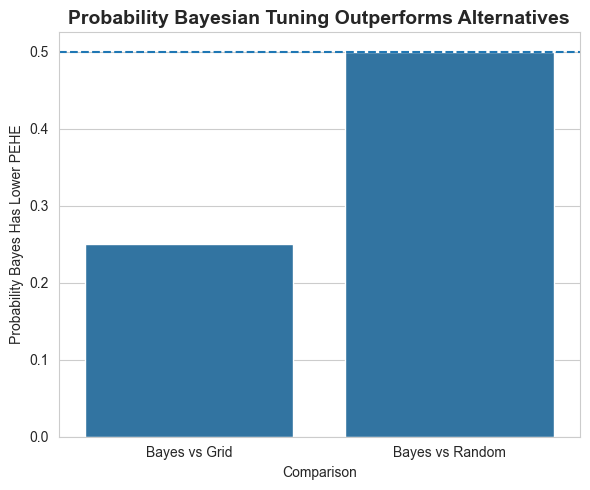

In [7]:
# Pivot results so each row is a comparable configuration
pivot = aggregated.pivot_table(
    index=["model", "setting"],
    columns="tuner",
    values="pehe_mean"
)

# Compute improvement indicators
pivot["bayes_beats_grid"] = pivot["bayes"] < pivot["grid"]
pivot["bayes_beats_random"] = pivot["bayes"] < pivot["random"]

# Convert to probabilities
prob_grid = pivot["bayes_beats_grid"].mean()
prob_random = pivot["bayes_beats_random"].mean()

print("Probability Bayesian beats Grid:", round(prob_grid, 3))
print("Probability Bayesian beats Random:", round(prob_random, 3))

# Plot
prob_df = pd.DataFrame({
    "Comparison": ["Bayes vs Grid", "Bayes vs Random"],
    "Probability Bayes Wins": [prob_grid, prob_random]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=prob_df,
    x="Comparison",
    y="Probability Bayes Wins"
)

plt.axhline(0.5, linestyle="--")

plt.title("Probability Bayesian Tuning Outperforms Alternatives", fontsize=14, fontweight="bold")
plt.ylabel("Probability Bayes Has Lower PEHE")
plt.xlabel("Comparison")

plt.tight_layout()
plt.show()

In [9]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Ensure dimension column exists
aggregated["dimension"] = aggregated["setting"].str.extract(r'(\d+)').astype(int)

# Treat factors as categorical
aggregated["tuner"] = aggregated["tuner"].astype("category")
aggregated["model"] = aggregated["model"].astype("category")
aggregated["dimension"] = aggregated["dimension"].astype("category")

# Fit linear model
model = smf.ols(
    "pehe_mean ~ C(tuner) + C(model) + C(dimension)",
    data=aggregated
).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nANOVA Variance Decomposition")
print("="*60)
print(anova_table.round(4))


ANOVA Variance Decomposition
              sum_sq     df       F  PR(>F)
C(tuner)      0.0223    2.0  5.3174  0.0051
C(model)      0.0027    1.0  1.3000  0.2546
C(dimension)  0.0461    3.0  7.3226  0.0001
Residual      1.6651  793.0     NaN     NaN


In [10]:
variance_share = anova_table["sum_sq"] / anova_table["sum_sq"].sum()

print((variance_share * 100).round(2))

C(tuner)         1.29
C(model)         0.16
C(dimension)     2.66
Residual        95.90
Name: sum_sq, dtype: float64


In [11]:
model_interactions = smf.ols(
    "pehe_mean ~ C(tuner) * C(model) + C(dimension)",
    data=aggregated
).fit()

sm.stats.anova_lm(model_interactions, typ=2)

,sum_sq,df,F,PR(>F)
C(tuner),0.022331,2.0,5.368228,0.004834
C(model),0.002730,1.0,1.312432,0.252301
C(dimension),0.046128,3.0,7.392576,0.000069
C(tuner):C(model),0.019918,2.0,4.788159,0.008571
Residual,1.645212,791.0,NaN,NaN


In [12]:
# Compute ranking within each experiment
ranked = aggregated.copy()

ranked["rank"] = ranked.groupby(["model","setting"])["pehe_mean"].rank(method="min")

ranked.head()

/var/folders/yg/yd_rkzv93459x04g3jzsjwcr0000gn/T/ipykernel_16166/2710634203.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ranked["rank"] = ranked.groupby(["model","setting"])["pehe_mean"].rank(method="min")


,model,setting,tuner,rep,pehe_mean,pehe_std,pehe_plug_mean,pehe_plug_std,dimension,rank
0,x_cb,1d,bayes,0,0.099102,NaN,0.315861,NaN,1,23.0
1,x_cb,1d,bayes,1,0.163602,NaN,0.536343,NaN,1,74.0
2,x_cb,1d,bayes,2,0.216457,NaN,0.557766,NaN,1,113.0
3,x_cb,1d,bayes,3,0.207491,NaN,0.365726,NaN,1,109.0
4,x_cb,1d,bayes,4,0.159065,NaN,0.414202,NaN,1,70.0


/var/folders/yg/yd_rkzv93459x04g3jzsjwcr0000gn/T/ipykernel_16166/4219182593.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rank = ranked.groupby("tuner")["rank"].mean().sort_values()


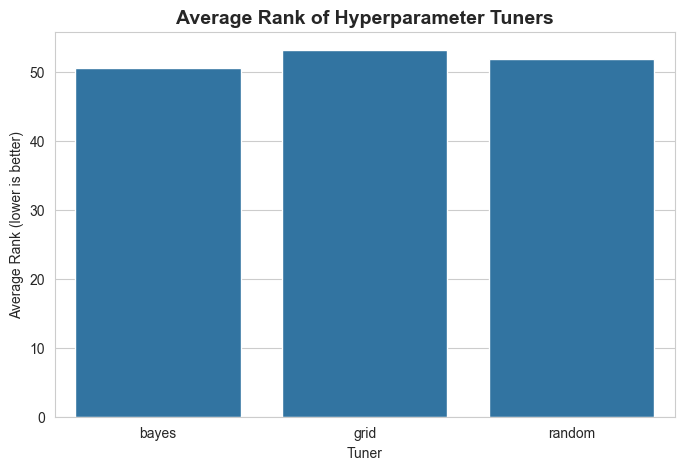


Average ranks:
tuner
bayes     50.493750
random    51.890625
grid      53.137500
Name: rank, dtype: float64


In [13]:
avg_rank = ranked.groupby("tuner")["rank"].mean().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_rank.index,
    y=avg_rank.values
)

plt.title("Average Rank of Hyperparameter Tuners", fontsize=14, fontweight="bold")
plt.ylabel("Average Rank (lower is better)")
plt.xlabel("Tuner")

plt.show()

print("\nAverage ranks:")
print(avg_rank)